# Candelaria Vial: priorización preventiva con datos abiertos

**Asignatura:** Técnicas de Aprendizaje de Máquina  
**Integrantes:** Steven Peinado, Alejandro Doncel, Jorge Olaya  
**Stakeholder principal:** Secretaría de Tránsito y Transporte de Candelaria, Valle del Cauca  
**Fuente principal:** [Accidentalidad Vial Municipio de Candelaria, Valle](https://www.datos.gov.co/Transporte/Accidentalidad-Vial-Municipio-de-Candelaria-Valle-/7wbf-88zm)

Este cuaderno reúne el informe técnico del proyecto. La idea es que el proceso se pueda seguir de principio a fin: qué problema planteamos, qué vimos en los datos, qué decisiones tomamos, cómo iteramos los modelos y qué limitaciones encontramos.

## 1. Elevator Pitch

### Problema real y stakeholder

La Secretaría de Tránsito y Transporte de Candelaria necesita decidir **dónde y cuándo concentrar acciones preventivas**. Los registros históricos permiten saber qué ocurrió, pero una decisión de prevención necesita algo adicional: una señal antes del siguiente periodo.

Nuestro problema no es solamente saber cuántos siniestros ocurrieron. También es **llegar tarde** cuando la información solo se usa de forma descriptiva.

El stakeholder principal es la **Secretaría de Tránsito y Transporte de Candelaria**. El resultado del proyecto podría servir como apoyo para priorizar revisión, monitoreo, campañas, señalización o validaciones en campo. No se plantea como una herramienta para sancionar personas ni para afirmar que un corregimiento es peligroso por naturaleza.

### Preguntas de negocio

1. **Regresión:** ¿cuántos siniestros se esperan el próximo mes por corregimiento?
2. **Clasificación:** ¿el próximo mes tendrá alta siniestralidad un corregimiento?

### ¿Por qué importa responderlas?

Los recursos para prevención no son ilimitados. Una señal territorial puede ayudar a ordenar qué zonas revisar primero y evitar que toda la planeación dependa del último accidente observado o de una regla igual para todos los corregimientos.

El costo de no mejorar esa anticipación es seguir trabajando de forma principalmente reactiva y posiblemente focalizar recursos donde no son más necesarios.

### ¿Por qué usar Machine Learning?

Un dashboard descriptivo es útil para responder **qué pasó**, pero no está diseñado para estimar directamente qué puede ocurrir el siguiente mes. Una regla simple, por ejemplo usar el mismo promedio histórico para todos los corregimientos, tampoco aprovecha al mismo tiempo el territorio, el comportamiento reciente y la estacionalidad.

Machine Learning nos permite comparar varios modelos que usan esas señales en conjunto y evaluar si realmente aportan algo frente a una referencia simple. Si los modelos no superaran esa referencia de forma razonable, la conclusión correcta sería quedarse con un análisis descriptivo y no forzar una solución predictiva.

### Hipótesis iniciales

1. La frecuencia mensual de siniestros cambia entre corregimientos.
2. El comportamiento reciente de un corregimiento aporta información para el mes siguiente.
3. Los rezagos, el calendario y el corregimiento permiten mejorar una regla básica basada únicamente en el promedio histórico.


### Registro de IA — Prompt 1: definición del problema

**Prompt usado**

> Actúa como directora de movilidad de Candelaria. Queremos priorizar intervenciones de seguridad vial con registros históricos y responder dos preguntas por corregimiento-mes: cuántos siniestros se esperan el próximo mes y si ese mes tendrá alta siniestralidad. Dame razones concretas para no financiar el proyecto, qué evidencia pedirías y qué daño podría causar un falso positivo o falso negativo.

**Respuesta o crítica que tomamos en cuenta**

La principal advertencia fue que un registro administrativo puede tener subregistro, cambios en la forma de reportar y diferencias de vigilancia entre zonas. También se señaló que una frecuencia alta no demuestra una causa y que una alerta mal usada puede mover recursos hacia zonas que ya reciben más atención.

**Decisión del equipo**

Se decidió separar el último año para prueba, trabajar con meses con y sin siniestros, usar solamente información disponible antes del mes objetivo y plantear la aplicación como apoyo a una decisión humana.


In [1]:
!pip -q install pandas numpy scikit-learn seaborn plotly

import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
DATA_URL = "https://www.datos.gov.co/resource/7wbf-88zm.csv?$limit=100000"
DOWNLOAD_TIME = datetime.now(timezone.utc).isoformat()

## 2. Diccionario y Justificación de Datos

### Fuente principal

Se utiliza el conjunto abierto **Accidentalidad Vial Municipio de Candelaria, Valle**, publicado en Datos Abiertos Colombia. Es la fuente principal porque contiene eventos de siniestralidad del municipio, su fecha, hora y ubicación territorial, que son elementos necesarios para construir el análisis por corregimiento y mes.


In [2]:
raw = pd.read_csv(DATA_URL)

expected_columns = {
    "clase_de_accidente",
    "gravedad",
    "vias",
    "corregimiento",
    "d_a_semana",
    "fecha_de_ocurrecia",
    "hora_ocurrencia"
}

assert expected_columns.issubset(raw.columns), "El esquema publicado cambió; revisar el diccionario."

print(f"Fecha UTC de descarga: {DOWNLOAD_TIME}")
print(f"Filas: {len(raw):,}")
print(f"Columnas: {raw.shape[1]}")
display(raw.head())

Fecha UTC de descarga: 2026-09-19T16:18:45.586596+00:00
Filas: 1,208
Columnas: 7


,clase_de_accidente,gravedad,vias,corregimiento,d_a_semana,fecha_de_ocurrecia,hora_ocurrencia
0,CHOQUE,DAÑOS,CALI-CANDELARIA,VILLAGORGONA,VIERNES,1/01/2021,01:40:00
1,CHOQUE,MUERTOS,CALI-CANDELARIA,JUANCHITO,VIERNES,1/01/2021,15:00:00
2,CHOQUE,DAÑOS,CALI-CANDELARIA,JUANCHITO,DOMINGO,3/01/2021,17:08:00
3,CHOQUE,DAÑOS,CALI-CANDELARIA,VILLAGORGONA,DOMINGO,3/01/2021,12:45:00
4,CHOQUE,DAÑOS,CALI-CANDELARIA,EL CARMELO,DOMINGO,3/01/2021,07:00:00


### Diccionario del conjunto de datos principal

| Campo | Tipo de dato | Descripción de negocio |
| --- | --- | --- |
| `clase_de_accidente` | Categórica / texto | Tipo de siniestro registrado. Se usa para descripción del conjunto, no como predictor del mes futuro. |
| `gravedad` | Categórica / texto | Clasificación de la consecuencia registrada, por ejemplo daños, heridos o muertos. Se usa en el EDA. |
| `vias` | Categórica / texto | Corredor o vía asociada al registro. Aporta contexto espacial en el análisis exploratorio. |
| `corregimiento` | Categórica / texto | Zona territorial de Candelaria. Es la unidad espacial principal del proyecto. |
| `d_a_semana` | Categórica / texto | Día de la semana informado en el registro. Se usa para revisión y análisis temporal. |
| `fecha_de_ocurrecia` | Fecha almacenada como texto | Fecha del siniestro. Permite construir año, mes, periodo y la partición temporal. |
| `hora_ocurrencia` | Hora almacenada como texto | Hora del evento. Se utiliza para revisar patrones horarios en el EDA. |

### Variables derivadas que se crean durante el proyecto

| Campo | Tipo | Uso |
| --- | --- | --- |
| `anio`, `mes` | Numéricas | Orden temporal y calendario. |
| `mes_seno`, `mes_coseno` | Numéricas | Representación cíclica del mes. |
| `siniestros_mes` | Numérica | Conteo mensual por corregimiento y objetivo de regresión. |
| `siniestros_lag_1` | Numérica | Siniestros del mes anterior del mismo corregimiento. |
| `promedio_3_meses_previo` | Numérica | Promedio de los tres meses previos. |
| `alta_siniestralidad` | Binaria | Objetivo de clasificación. Vale 1 cuando hay 5 o más siniestros en el corregimiento-mes. |

### Datos complementarios

En esta versión **no integramos una fuente externa adicional**. Preferimos primero medir cuánto se puede aprender con el registro oficial disponible y no agregar una fuente que no tuviera cobertura y llaves suficientemente claras.

Sí identificamos datos que podrían mejorar una siguiente versión: aforo vehicular, clima, obras, eventos, controles y estado de la vía.

La estrategia de integración sería principalmente temporal y territorial. Por ejemplo, un aforo podría agregarse por corregimiento-mes; el clima podría resumirse por fecha y mes; y obras o eventos podrían relacionarse por periodo y ubicación. Antes de integrarlos habría que revisar que las zonas y fechas sean comparables con las del conjunto principal.


In [3]:
quality = pd.DataFrame({
    "tipo": raw.dtypes.astype(str),
    "nulos": raw.isna().sum(),
    "n_unicos": raw.nunique(dropna=True)
})

inventory = pd.DataFrame({
    "medida": [
        "Filas",
        "Columnas",
        "Corregimientos",
        "Clases de gravedad",
        "Filas exactamente repetidas"
    ],
    "valor": [
        len(raw),
        raw.shape[1],
        raw["corregimiento"].nunique(dropna=True),
        raw["gravedad"].nunique(dropna=True),
        raw.duplicated().sum()
    ]
})

display(inventory)
display(quality)

,medida,valor
0,Filas,1208
1,Columnas,7
2,Corregimientos,36
3,Clases de gravedad,3
4,Filas exactamente repetidas,4


,tipo,nulos,n_unicos
clase_de_accidente,object,2,6
gravedad,object,0,3
vias,object,0,113
corregimiento,object,0,36
d_a_semana,object,13,7
fecha_de_ocurrecia,object,0,857
hora_ocurrencia,object,13,186


### Decisión frente a calidad de los datos

En la ejecución usada durante el desarrollo aparecieron algunos valores faltantes y unas pocas filas exactamente repetidas. No eliminamos automáticamente esas filas repetidas porque el conjunto no trae un identificador único del evento que permita asegurar que se trata del mismo siniestro duplicado y no de dos registros con los mismos campos publicados.

También observamos nombres territoriales que podrían corresponder a formas distintas de registrar una misma zona. En esta entrega se normalizan espacios y mayúsculas, pero no se fusionan categorías sin una confirmación externa de la Secretaría.


In [4]:
def clean_text(series):
    return (
        series.fillna("SIN_DATO")
        .astype(str)
        .str.strip()
        .str.upper()
        .replace({"": "SIN_DATO", "NAN": "SIN_DATO"})
    )

incidents = raw.copy()

for column in ["vias", "corregimiento", "d_a_semana", "gravedad", "clase_de_accidente"]:
    incidents[column] = clean_text(incidents[column])

incidents["fecha"] = pd.to_datetime(
    incidents["fecha_de_ocurrecia"],
    dayfirst=True,
    errors="coerce"
)

parsed_time = pd.to_timedelta(
    incidents["hora_ocurrencia"],
    errors="coerce"
)

incidents["hora"] = parsed_time.dt.total_seconds() / 3600
incidents = incidents.dropna(subset=["fecha"]).copy()
incidents["anio"] = incidents["fecha"].dt.year.astype(int)
incidents["mes"] = incidents["fecha"].dt.month.astype(int)
incidents["dia_semana_num"] = incidents["fecha"].dt.dayofweek.astype(int)
incidents["es_fin_de_semana"] = (incidents["dia_semana_num"] >= 5).astype(int)
incidents["mes_seno"] = np.sin(2 * np.pi * incidents["mes"] / 12)
incidents["mes_coseno"] = np.cos(2 * np.pi * incidents["mes"] / 12)
incidents["lesion_o_muerte"] = incidents["gravedad"].isin(["HERIDOS", "MUERTOS"]).astype(int)

print("Cobertura:", incidents["fecha"].min().date(), "a", incidents["fecha"].max().date())
display(incidents[["fecha", "hora", "gravedad", "vias", "corregimiento"]].head())

Cobertura: 2021-01-01 a 2025-12-02


,fecha,hora,gravedad,vias,corregimiento
0,2021-01-01,1.666667,DAÑOS,CALI-CANDELARIA,VILLAGORGONA
1,2021-01-01,15.000000,MUERTOS,CALI-CANDELARIA,JUANCHITO
2,2021-01-03,17.133333,DAÑOS,CALI-CANDELARIA,JUANCHITO
3,2021-01-03,12.750000,DAÑOS,CALI-CANDELARIA,VILLAGORGONA
4,2021-01-03,7.000000,DAÑOS,CALI-CANDELARIA,EL CARMELO


## 3. Análisis Exploratorio de Datos (EDA con narrativa)

El EDA se organizó alrededor de las preguntas del proyecto. No buscamos acumular gráficas, sino revisar si hay diferencias territoriales, comportamiento temporal y señales históricas que tengan sentido para predecir el mes siguiente.

Las preguntas principales fueron:

- ¿La composición de los registros cambia entre años?
- ¿Qué corregimientos concentran más eventos registrados?
- ¿Hay patrones temporales por mes, día u hora?
- ¿Qué tan dispersos y asimétricos son los conteos mensuales?
- ¿El mes anterior y el promedio reciente tienen relación con el conteo actual?


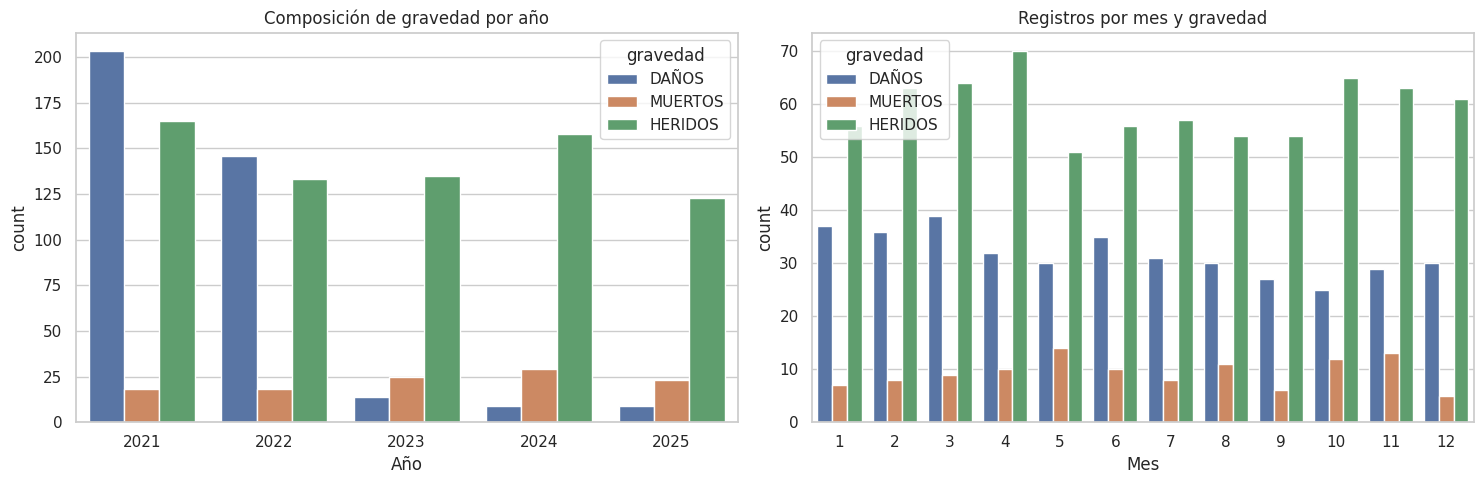

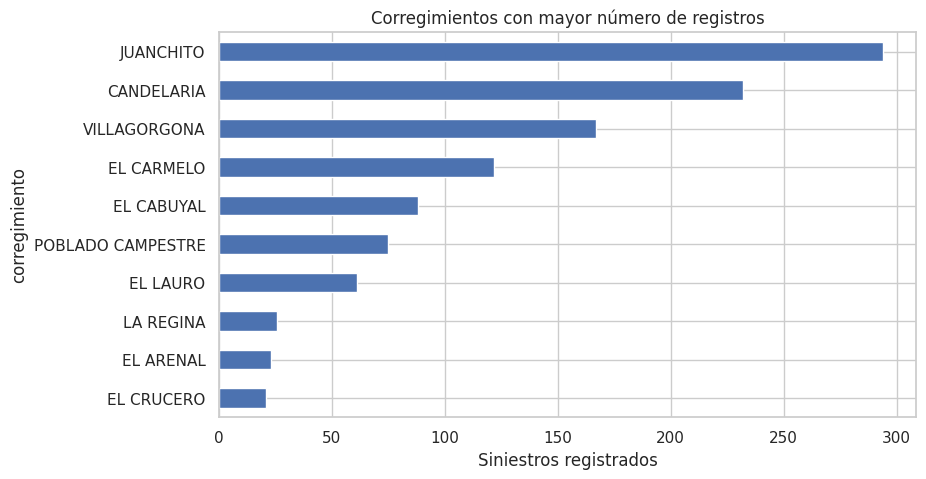

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=incidents, x="anio", hue="gravedad", ax=axes[0])
axes[0].set_title("Composición de gravedad por año")
axes[0].set_xlabel("Año")

sns.countplot(data=incidents, x="mes", hue="gravedad", ax=axes[1])
axes[1].set_title("Registros por mes y gravedad")
axes[1].set_xlabel("Mes")

plt.tight_layout()
plt.show()

top_locations = incidents["corregimiento"].value_counts().head(10).sort_values()

ax = top_locations.plot.barh(
    figsize=(9, 5),
    title="Corregimientos con mayor número de registros"
)
ax.set_xlabel("Siniestros registrados")
plt.show()

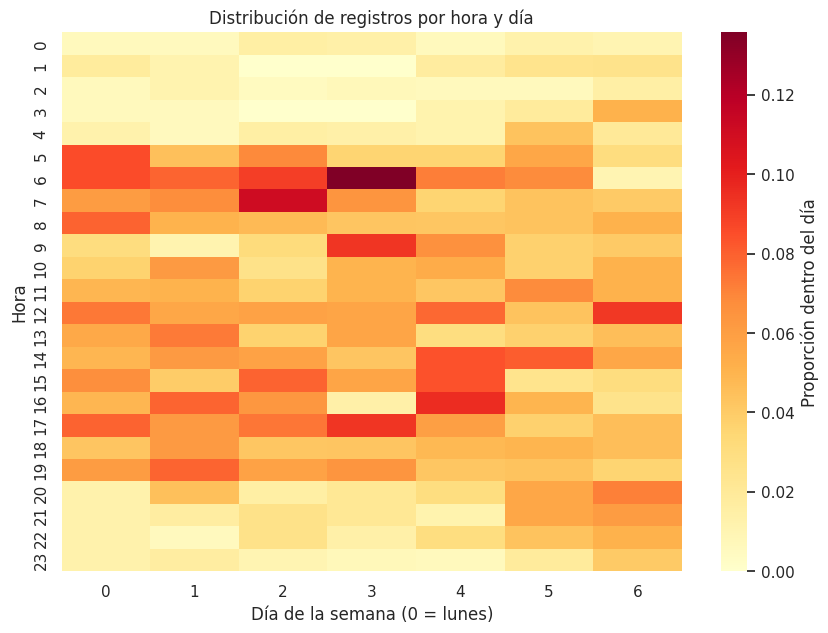

gravedad,DAÑOS,HERIDOS,MUERTOS
anio,,,
2021,0.526,0.427,0.047
2022,0.492,0.448,0.061
2023,0.080,0.776,0.144
2024,0.046,0.806,0.148
2025,0.058,0.794,0.148


In [6]:
hour_data = incidents.dropna(subset=["hora"]).copy()
hour_data["hora_entera"] = hour_data["hora"].astype(int)

pivot = pd.crosstab(
    hour_data["hora_entera"],
    hour_data["dia_semana_num"],
    normalize="columns"
)

plt.figure(figsize=(10, 7))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    cbar_kws={"label": "Proporción dentro del día"}
)
plt.title("Distribución de registros por hora y día")
plt.xlabel("Día de la semana (0 = lunes)")
plt.ylabel("Hora")
plt.show()

severity_year = pd.crosstab(
    incidents["anio"],
    incidents["gravedad"],
    normalize="index"
).round(3)

display(severity_year)

### Storytelling de los datos: ¿qué nos está diciendo la siniestralidad?

El análisis exploratorio mostró que la siniestralidad no se comporta de la misma manera en todos los corregimientos ni en todos los meses. Esto fue importante porque nuestra pregunta inicial no buscaba solamente describir cuántos siniestros habían ocurrido, sino evaluar si el comportamiento histórico podía aportar información para anticipar el siguiente mes.

Al analizar los conteos mensuales encontramos que la mayoría de los corregimientos-mes presentan pocos siniestros, mientras que los meses con cinco o más eventos son poco frecuentes. Al definir estos últimos como ALTA siniestralidad, encontramos que representan aproximadamente el 3,9 % de las observaciones, frente a un 96,1 % de NO ALTA.

Este fue uno de los hallazgos más importantes del EDA. Aunque inicialmente esperábamos encontrar diferencias territoriales y temporales, no esperábamos que los periodos de alta siniestralidad fueran tan escasos. Esto cambió la forma en la que posteriormente evaluamos la clasificación: una accuracy alta por sí sola podía resultar engañosa.

También observamos variación entre corregimientos y a través del tiempo. Esto nos llevó a considerar que el comportamiento reciente podía aportar información sobre el siguiente periodo. Por esta razón construimos variables como los siniestros del mes anterior y el promedio de los tres meses previos.
En conjunto, el EDA nos llevó de una pregunta descriptiva —“¿cómo se han distribuido los siniestros?”— a las dos preguntas predictivas del proyecto:
¿cuántos siniestros se esperan el próximo mes? y ¿el próximo mes tendrá alta siniestralidad?

### Hallazgo inesperado y posible sesgo de registro

La composición entre `DAÑOS`, `HERIDOS` y `MUERTOS` cambia bastante entre algunos años. No interpretamos ese cambio automáticamente como una mejora o un empeoramiento de la seguridad vial. También puede estar relacionado con cambios en el registro o en la cobertura de la información.

Por esta razón la gravedad se mantiene como parte del análisis exploratorio, pero **no se usa como objetivo de la clasificación final**.


In [7]:
start = incidents["fecha"].min().to_period("M")
end = incidents["fecha"].max().to_period("M")
periods = pd.period_range(start, end, freq="M")

locations = pd.DataFrame({
    "corregimiento": sorted(incidents["corregimiento"].unique())
})

monthly = locations.merge(
    pd.DataFrame({"periodo": periods}),
    how="cross"
)

monthly["fecha"] = monthly["periodo"].dt.to_timestamp()

observed = (
    incidents.assign(periodo=incidents["fecha"].dt.to_period("M"))
    .groupby(["corregimiento", "periodo"], as_index=False)
    .size()
    .rename(columns={"size": "siniestros_mes"})
)

monthly = monthly.merge(
    observed,
    on=["corregimiento", "periodo"],
    how="left"
)

monthly["siniestros_mes"] = monthly["siniestros_mes"].fillna(0).astype(int)
monthly = monthly.sort_values(["corregimiento", "fecha"]).reset_index(drop=True)

groups = monthly.groupby(
    "corregimiento",
    observed=True
)["siniestros_mes"]

monthly["siniestros_lag_1"] = groups.shift(1).fillna(0)

monthly["promedio_3_meses_previo"] = groups.transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0)

monthly["anio"] = monthly["fecha"].dt.year.astype(int)
monthly["mes"] = monthly["fecha"].dt.month.astype(int)
monthly["mes_seno"] = np.sin(2 * np.pi * monthly["mes"] / 12)
monthly["mes_coseno"] = np.cos(2 * np.pi * monthly["mes"] / 12)

print("Tamaño del panel mensual:", monthly.shape)
display(monthly.head())

Tamaño del panel mensual: (2160, 10)


,corregimiento,periodo,fecha,siniestros_mes,siniestros_lag_1,promedio_3_meses_previo,anio,mes,mes_seno,mes_coseno
0,BUCHITOLO,2021-01,2021-01-01,0,0.0,0.000000,2021,1,0.500000,8.660254e-01
1,BUCHITOLO,2021-02,2021-02-01,1,0.0,0.000000,2021,2,0.866025,5.000000e-01
2,BUCHITOLO,2021-03,2021-03-01,0,1.0,0.500000,2021,3,1.000000,6.123234e-17
3,BUCHITOLO,2021-04,2021-04-01,0,0.0,0.333333,2021,4,0.866025,-5.000000e-01
4,BUCHITOLO,2021-05,2021-05-01,0,0.0,0.333333,2021,5,0.500000,-8.660254e-01


,count,mean,std,mediana,IQR,min,max,sesgo
siniestros_mes,2160.0,0.559,1.569,0.0,0.000,0.0,17.0,4.407
siniestros_lag_1,2160.0,0.559,1.569,0.0,0.000,0.0,17.0,4.408
promedio_3_meses_previo,2160.0,0.570,1.429,0.0,0.333,0.0,12.0,3.939


,siniestros_mes,siniestros_lag_1,promedio_3_meses_previo,mes
siniestros_mes,1.000,0.685,0.750,-0.011
siniestros_lag_1,0.685,1.000,0.891,-0.006
promedio_3_meses_previo,0.750,0.891,1.000,-0.018
mes,-0.011,-0.006,-0.018,1.000


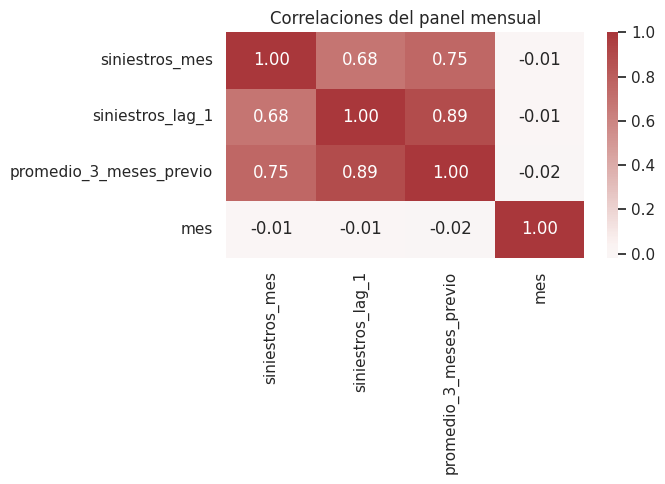

,media,mediana,desviacion,minimo,maximo
corregimiento,,,,,
JUANCHITO,4.900,4.0,3.790,0,14
CANDELARIA,3.867,4.0,3.816,0,17
VILLAGORGONA,2.783,2.5,2.051,0,9
EL CARMELO,2.033,2.0,1.449,0,6
EL CABUYAL,1.467,1.0,1.295,0,5
POBLADO CAMPESTRE,1.250,1.0,1.373,0,5
EL LAURO,1.017,1.0,1.269,0,5
LA REGINA,0.433,0.0,0.909,0,5
EL ARENAL,0.383,0.0,0.666,0,3


In [8]:
monthly_stats = monthly[
    ["siniestros_mes", "siniestros_lag_1", "promedio_3_meses_previo"]
].describe().T

monthly_stats["mediana"] = monthly[
    ["siniestros_mes", "siniestros_lag_1", "promedio_3_meses_previo"]
].median()

monthly_stats["IQR"] = (
    monthly[
        ["siniestros_mes", "siniestros_lag_1", "promedio_3_meses_previo"]
    ].quantile(0.75)
    - monthly[
        ["siniestros_mes", "siniestros_lag_1", "promedio_3_meses_previo"]
    ].quantile(0.25)
)

monthly_stats["sesgo"] = monthly[
    ["siniestros_mes", "siniestros_lag_1", "promedio_3_meses_previo"]
].skew()

display(
    monthly_stats[
        ["count", "mean", "std", "mediana", "IQR", "min", "max", "sesgo"]
    ].round(3)
)

monthly_corr = monthly[
    ["siniestros_mes", "siniestros_lag_1", "promedio_3_meses_previo", "mes"]
].corr()

display(monthly_corr.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(
    monthly_corr,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="vlag"
)
plt.title("Correlaciones del panel mensual")
plt.tight_layout()
plt.show()

monthly_summary = (
    monthly.groupby("corregimiento")["siniestros_mes"]
    .agg(
        media="mean",
        mediana="median",
        desviacion="std",
        minimo="min",
        maximo="max"
    )
    .sort_values("media", ascending=False)
)

display(monthly_summary.round(3))

### Narrativa de los principales hallazgos

En la ejecución usada durante el desarrollo se formó un panel de **2.160 observaciones corregimiento-mes**. Cerca del **79,4 %** de esas observaciones tenían cero siniestros. La mediana del conteo mensual fue 0 y el máximo observado fue 17.

También encontramos una distribución bastante asimétrica: la mayoría de los corregimiento-mes están en valores bajos y unos pocos periodos tienen conteos mucho mayores. Esto hace que un promedio general sea una referencia demasiado simple para representar todo el territorio.

El conteo mensual mostró una asociación positiva con el mes anterior y con el promedio de los tres meses previos. En la ejecución del análisis, las correlaciones fueron aproximadamente **0,685** y **0,750**, respectivamente. No interpretamos estas relaciones como causas; únicamente indican que el comportamiento reciente contiene información que puede ser útil para el siguiente mes.

### Relación con las preguntas de negocio

Estos hallazgos apoyan tres decisiones del proyecto:

1. Trabajar a nivel de **corregimiento-mes** y no únicamente con un total municipal.
2. Crear variables que resumen el comportamiento reciente.
3. Evaluar los modelos con una separación temporal, porque el objetivo es anticipar un periodo futuro.


### Registro de IA — Prompt 2: revisión del EDA

**Prompt usado**

> Estoy analizando un conjunto de accidentalidad vial para decidir dónde priorizar intervenciones. Mi EDA contiene conteos por año, mes, corregimiento y una tabla hora-día. ¿Qué análisis estadísticos mínimos faltan para evitar una narrativa puramente descriptiva y qué sesgos debo revisar?

**Respuesta o crítica que tomamos en cuenta**

Se recomendó complementar las gráficas con tendencia central, dispersión, asimetría, correlaciones y tablas de contingencia. También se recomendó no confundir una asociación con causalidad y revisar posibles cambios de registro entre años.

**Decisión del equipo**

Se agregaron media, mediana, desviación, IQR, sesgo, correlaciones del panel mensual y una tabla de contingencia entre año y gravedad. Los hallazgos se conectaron con las variables que luego entran al modelado.


## 4. Preparación de Datos e Ingeniería de Características

La unidad de modelado es **corregimiento-mes**. Para cada corregimiento se construye una serie mensual completa, incluyendo los meses en los que no aparece ningún siniestro registrado.

Las principales transformaciones son:

- `siniestros_lag_1`: número de siniestros del mes anterior.
- `promedio_3_meses_previo`: promedio de los tres meses anteriores.
- `anio` y `mes`: información de calendario.
- `mes_seno` y `mes_coseno`: forma cíclica de representar el mes.
- `corregimiento`: variable territorial categórica.

Para las variables numéricas usamos imputación con la mediana y estandarización dentro del pipeline. Para `corregimiento` usamos imputación con la categoría más frecuente y One-Hot Encoding. Estas transformaciones se ajustan solamente con los datos de entrenamiento para no introducir información futura.

No eliminamos automáticamente los conteos mensuales altos usando IQR porque un mes con muchos siniestros puede ser precisamente uno de los casos que queremos estudiar. Solo se eliminaría un valor si existiera evidencia de que corresponde a un error de registro.

No usamos `gravedad`, `clase_de_accidente` ni información del propio mes objetivo como predictores porque serían datos conocidos durante o después del evento que se intenta anticipar.

La definición final de la clasificación es **ALTA = 5 o más siniestros en un corregimiento-mes**. Esta definición no se baja para balancear las clases.

### Registro de IA — Prompt 3: preparación y fuga de información

**Prompt usado**

> Para dos modelos preventivos a nivel corregimiento-mes, uno de regresión del conteo y otro de clasificación de alta siniestralidad, ¿qué decisiones de preparación podrían hacerme perder información útil o generar fuga de información? También revisa si tendría sentido eliminar automáticamente los conteos altos como outliers.

**Respuesta o crítica que tomamos en cuenta**

Los rezagos deben usar únicamente meses anteriores, el conteo real del mes que se quiere predecir no puede entrar como predictor y el último año no debe utilizarse para escoger hiperparámetros. También se advirtió que eliminar automáticamente los meses con conteos altos podría borrar precisamente los casos de mayor interés para el proyecto.

**Decisión del equipo**

Se usan imputación, codificación y escalado dentro de pipelines. No se eliminan conteos altos solamente por una regla de IQR. Se usa información anterior a 2024 para el ajuste inicial, **2024 como validación temporal** y **2025 como prueba final**. El test se deja intacto hasta terminar las decisiones de modelado.

In [9]:
test_year = int(incidents["anio"].max())
validation_year = test_year - 1

inc_train = incidents[incidents["anio"] < test_year].copy()
inc_test = incidents[incidents["anio"] == test_year].copy()

mon_train = monthly[monthly["anio"] < test_year].copy()
mon_test = monthly[monthly["anio"] == test_year].copy()

mon_fit = monthly[monthly["anio"] < validation_year].copy()
mon_val = monthly[monthly["anio"] == validation_year].copy()

HIGH_THRESHOLD = 5

for frame in [mon_train, mon_test, mon_fit, mon_val]:
    frame["alta_siniestralidad"] = (
        frame["siniestros_mes"] >= HIGH_THRESHOLD
    ).astype(int)

print(f"Ajuste inicial: hasta {validation_year - 1}")
print(f"Validación temporal: {validation_year}")
print(f"Prueba final: {test_year}")
print(f"Definición de ALTA: {HIGH_THRESHOLD} o más siniestros")

display(
    mon_train["alta_siniestralidad"]
    .value_counts()
    .rename(index={0: "NO ALTA", 1: "ALTA"})
    .rename("conteo")
)

display(
    (
        mon_train["alta_siniestralidad"]
        .value_counts(normalize=True)
        .rename(index={0: "NO ALTA", 1: "ALTA"})
        .mul(100)
        .rename("porcentaje")
        .round(2)
    )
)

def preprocessor(categorical, numeric):
    return ColumnTransformer([
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "ohe",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        min_frequency=5
                    )
                )
            ]),
            categorical
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scale", StandardScaler())
            ]),
            numeric
        )
    ])

Ajuste inicial: hasta 2023
Validación temporal: 2024
Prueba final: 2025
Definición de ALTA: 5 o más siniestros


,conteo
alta_siniestralidad,
NO ALTA,1661
ALTA,67


,porcentaje
alta_siniestralidad,
NO ALTA,96.12
ALTA,3.88


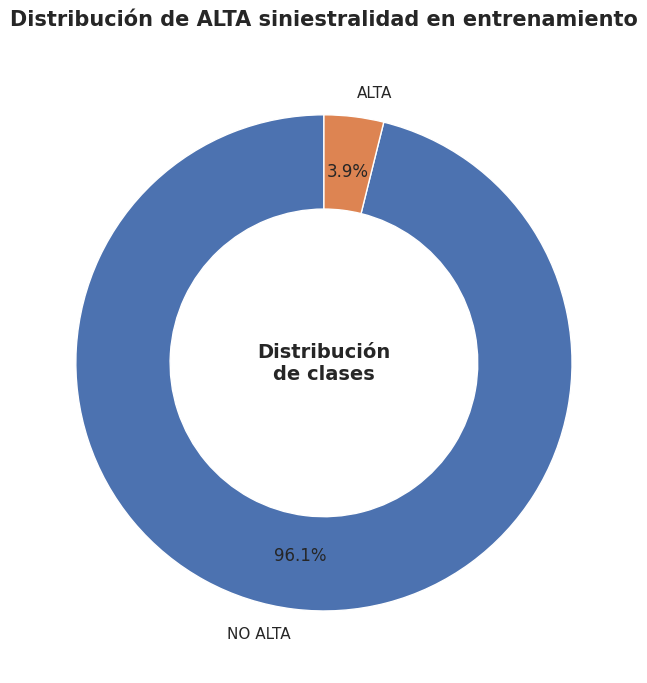

In [10]:
class_counts = (
    mon_train["alta_siniestralidad"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

values = class_counts.values
labels = ["NO ALTA", "ALTA"]

fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78,
    wedgeprops={"width": 0.38, "edgecolor": "white"}
)

ax.text(
    0,
    0,
    "Distribución\nde clases",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "Distribución de ALTA siniestralidad en entrenamiento",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

## 5. Modelado, Evaluación e Interpretación

La evaluación sigue la misma idea para los dos problemas: las decisiones se toman con datos anteriores al test y **2025 se usa solamente al final**.

La iteración no se entiende como probar modelos hasta que el test se vea bien. La iteración ocurre sobre el conjunto de validación: se comparan alternativas, se ajustan hiperparámetros y después se congela la decisión.


### 5.1 Problema de regresión: ¿cuántos siniestros se esperan?

Se comparan tres algoritmos vistos en clase:

- **Regresión Lineal:** sirve como modelo sencillo e interpretable y permite revisar si una relación aproximadamente lineal es suficiente.
- **Árbol de Decisión:** permite relaciones no lineales y reglas distintas según las características.
- **Random Forest Regressor:** combina varios árboles y puede capturar relaciones e interacciones más complejas.

También se incluye como referencia el **promedio histórico**, no como un cuarto algoritmo del curso, sino como una regla básica que el modelo debería ser capaz de superar para justificar su uso.

Las métricas reportadas son **MSE, RMSE, MAE y R²**.

Para Árbol de Decisión y Random Forest se usa una búsqueda aleatoria de **10 combinaciones de hiperparámetros** con `ParameterSampler`. La selección se hace únicamente con la validación temporal de 2024 y el criterio principal es el **MAE más bajo**. Después de seleccionar la configuración, el modelo se reentrena con 2021–2024 y se evalúa una sola vez en 2025.

### Registro de IA — Prompt 4: optimización de regresión

**Prompt usado**

> Si un Random Forest supera una referencia simple, ¿basta con elegirlo? ¿Cómo mostramos que la mejora no depende de parámetros escogidos a mano ni de mirar el año de prueba?

**Respuesta o crítica que tomamos en cuenta**

La selección debía ocurrir antes del test. Para Árbol y Random Forest se recomendó probar varias combinaciones de hiperparámetros usando 2024 como validación. La Regresión Lineal no necesita una búsqueda equivalente.

**Decisión del equipo**

Se usa `ParameterSampler` con 10 combinaciones para Árbol y Random Forest. Se comparan los modelos en validación temporal y el modelo con menor MAE se vuelve a entrenar con 2021–2024. Solo después se evalúa una vez en 2025. También se reportan los hiperparámetros finales para que la selección sea reproducible.

In [11]:
reg_cat = ["corregimiento"]
reg_num = [
    "anio",
    "mes",
    "mes_seno",
    "mes_coseno",
    "siniestros_lag_1",
    "promedio_3_meses_previo"
]
reg_features = reg_cat + reg_num

reg_base_models = {
    "Regresión lineal": LinearRegression(),
    "Árbol de decisión": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE)
}

reg_search_spaces = {
    "Árbol de decisión": {
        "model__max_depth": [3, 4, 5, 6, 8, 10, None],
        "model__min_samples_leaf": [2, 4, 6, 8, 12, 16]
    },
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [5, 8, 10, 12, None],
        "model__min_samples_leaf": [2, 4, 6, 8],
        "model__max_features": [0.5, 0.8, 1.0]
    }
}

reg_validation_rows = []
reg_best_params = {}

baseline_val = np.repeat(mon_fit["siniestros_mes"].mean(), len(mon_val))
baseline_val_mse = mean_squared_error(mon_val["siniestros_mes"], baseline_val)
reg_validation_rows.append({
    "Modelo": "Baseline: promedio histórico",
    "MSE": baseline_val_mse,
    "RMSE": baseline_val_mse ** 0.5,
    "MAE": mean_absolute_error(mon_val["siniestros_mes"], baseline_val),
    "R2": r2_score(mon_val["siniestros_mes"], baseline_val)
})

linear_pipe = Pipeline([
    ("prep", preprocessor(reg_cat, reg_num)),
    ("model", reg_base_models["Regresión lineal"])
])
linear_pipe.fit(mon_fit[reg_features], mon_fit["siniestros_mes"])
linear_val_pred = linear_pipe.predict(mon_val[reg_features])
linear_val_mse = mean_squared_error(mon_val["siniestros_mes"], linear_val_pred)
reg_validation_rows.append({
    "Modelo": "Regresión lineal",
    "MSE": linear_val_mse,
    "RMSE": linear_val_mse ** 0.5,
    "MAE": mean_absolute_error(mon_val["siniestros_mes"], linear_val_pred),
    "R2": r2_score(mon_val["siniestros_mes"], linear_val_pred)
})
reg_best_params["Regresión lineal"] = {}

for name in ["Árbol de decisión", "Random Forest"]:
    sampled = list(ParameterSampler(reg_search_spaces[name], n_iter=10, random_state=RANDOM_STATE))
    best_mae = np.inf
    best_params = None
    best_pred = None

    for params in sampled:
        candidate = Pipeline([
            ("prep", preprocessor(reg_cat, reg_num)),
            ("model", reg_base_models[name])
        ])
        candidate.set_params(**params)
        candidate.fit(mon_fit[reg_features], mon_fit["siniestros_mes"])
        val_pred = candidate.predict(mon_val[reg_features])
        mae = mean_absolute_error(mon_val["siniestros_mes"], val_pred)
        if mae < best_mae:
            best_mae = mae
            best_params = params
            best_pred = val_pred

    reg_best_params[name] = best_params
    best_mse = mean_squared_error(mon_val["siniestros_mes"], best_pred)
    reg_validation_rows.append({
        "Modelo": name,
        "MSE": best_mse,
        "RMSE": best_mse ** 0.5,
        "MAE": mean_absolute_error(mon_val["siniestros_mes"], best_pred),
        "R2": r2_score(mon_val["siniestros_mes"], best_pred)
    })

reg_validation_results = pd.DataFrame(reg_validation_rows).sort_values("MAE").reset_index(drop=True)
display(reg_validation_results.round(4))
selected_reg_name = reg_validation_results.iloc[0]["Modelo"]

if selected_reg_name == "Baseline: promedio histórico":
    final_reg_pred = np.repeat(mon_train["siniestros_mes"].mean(), len(mon_test))
    selected_reg_pipe = None
else:
    selected_reg_pipe = Pipeline([
        ("prep", preprocessor(reg_cat, reg_num)),
        ("model", reg_base_models[selected_reg_name])
    ])
    if reg_best_params[selected_reg_name]:
        selected_reg_pipe.set_params(**reg_best_params[selected_reg_name])
    selected_reg_pipe.fit(mon_train[reg_features], mon_train["siniestros_mes"])
    final_reg_pred = selected_reg_pipe.predict(mon_test[reg_features])

baseline_test = np.repeat(mon_train["siniestros_mes"].mean(), len(mon_test))
baseline_test_mse = mean_squared_error(mon_test["siniestros_mes"], baseline_test)
final_reg_mse = mean_squared_error(mon_test["siniestros_mes"], final_reg_pred)

reg_test_results = pd.DataFrame([
    {
        "Modelo": "Baseline: promedio histórico",
        "MSE": baseline_test_mse,
        "RMSE": baseline_test_mse ** 0.5,
        "MAE": mean_absolute_error(mon_test["siniestros_mes"], baseline_test),
        "R2": r2_score(mon_test["siniestros_mes"], baseline_test)
    },
    {
        "Modelo": f"Seleccionado: {selected_reg_name}",
        "MSE": final_reg_mse,
        "RMSE": final_reg_mse ** 0.5,
        "MAE": mean_absolute_error(mon_test["siniestros_mes"], final_reg_pred),
        "R2": r2_score(mon_test["siniestros_mes"], final_reg_pred)
    }
])

reg_optimization_summary = pd.DataFrame([
    {
        "Modelo": "Regresión lineal",
        "Método": "Sin búsqueda",
        "Criterio": "MAE en validación 2024",
        "Hiperparámetros finales": "Parámetros por defecto"
    },
    {
        "Modelo": "Árbol de decisión",
        "Método": "ParameterSampler, 10 combinaciones",
        "Criterio": "MAE en validación 2024",
        "Hiperparámetros finales": str(reg_best_params["Árbol de decisión"])
    },
    {
        "Modelo": "Random Forest",
        "Método": "ParameterSampler, 10 combinaciones",
        "Criterio": "MAE en validación 2024",
        "Hiperparámetros finales": str(reg_best_params["Random Forest"])
    }
])

display(reg_test_results.round(4))
display(reg_optimization_summary)
print("Modelo seleccionado con validación:", selected_reg_name)
print("Parámetros seleccionados:", reg_best_params.get(selected_reg_name, {}))

,Modelo,MSE,RMSE,MAE,R2
0,Random Forest,0.7554,0.8691,0.4166,0.2733
1,Árbol de decisión,0.8327,0.9125,0.4377,0.1990
2,Regresión lineal,1.5132,1.2301,0.7606,-0.4556
3,Baseline: promedio histórico,1.0826,1.0405,0.8119,-0.0414


,Modelo,MSE,RMSE,MAE,R2
0,Baseline: promedio histórico,0.7929,0.8904,0.7171,-0.0860
1,Seleccionado: Random Forest,0.6623,0.8138,0.4565,0.0928


,Modelo,Método,Criterio,Hiperparámetros finales
0,Regresión lineal,Sin búsqueda,MAE en validación 2024,Parámetros por defecto
1,Árbol de decisión,"ParameterSampler, 10 combinaciones",MAE en validación 2024,"{'model__min_samples_leaf': 8, 'model__max_dep..."
2,Random Forest,"ParameterSampler, 10 combinaciones",MAE en validación 2024,"{'model__n_estimators': 300, 'model__min_sampl..."


Modelo seleccionado con validación: Random Forest
Parámetros seleccionados: {'model__n_estimators': 300, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}


,corregimiento,fecha,siniestros_mes,prediccion,error_absoluto
2099,VILLAGORGONA,2025-12-01,0,3.66,3.66
2098,VILLAGORGONA,2025-11-01,6,2.36,3.64
2093,VILLAGORGONA,2025-06-01,5,1.97,3.03
1013,JUANCHITO,2025-06-01,0,3.01,3.01
479,EL CARMELO,2025-12-01,0,2.94,2.94
1619,POBLADO CAMPESTRE,2025-12-01,0,2.85,2.85
2095,VILLAGORGONA,2025-08-01,0,2.77,2.77
2088,VILLAGORGONA,2025-01-01,0,2.73,2.73
1009,JUANCHITO,2025-02-01,0,2.67,2.67
416,EL CABUYAL,2025-09-01,4,1.41,2.59


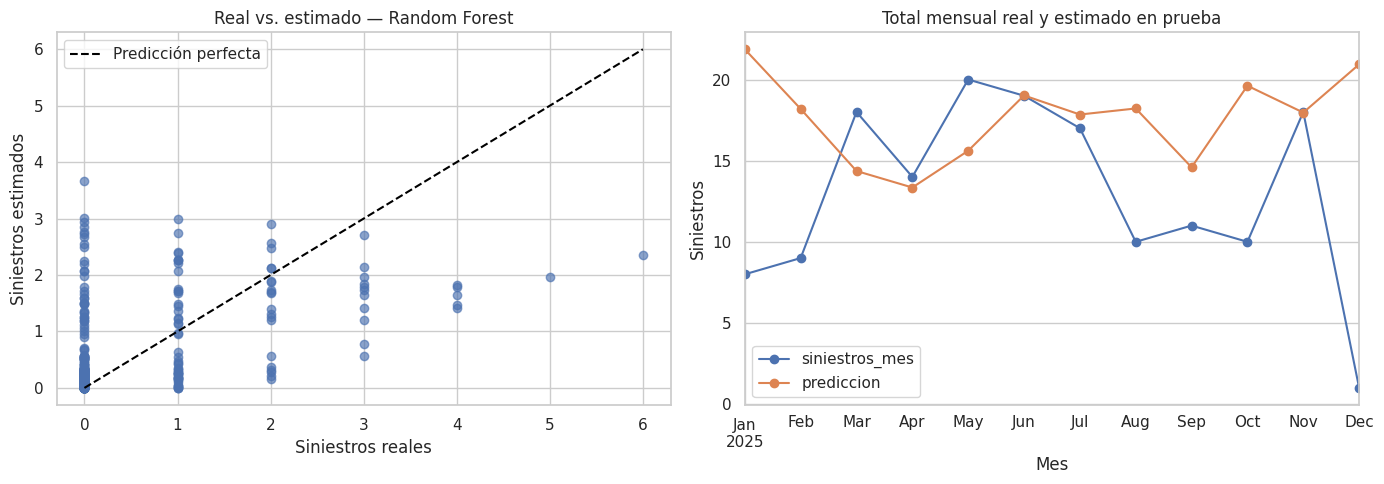

In [12]:
reg_diagnostic = mon_test[
    ["corregimiento", "fecha", "siniestros_mes"]
].copy()

reg_diagnostic["prediccion"] = final_reg_pred
reg_diagnostic["error_absoluto"] = (
    reg_diagnostic["siniestros_mes"]
    - reg_diagnostic["prediccion"]
).abs()

display(
    reg_diagnostic
    .sort_values("error_absoluto", ascending=False)
    .head(10)
    .round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    reg_diagnostic["siniestros_mes"],
    reg_diagnostic["prediccion"],
    alpha=0.65
)

limit = max(
    reg_diagnostic["siniestros_mes"].max(),
    reg_diagnostic["prediccion"].max()
)

axes[0].plot(
    [0, limit],
    [0, limit],
    "--",
    color="black",
    label="Predicción perfecta"
)

axes[0].set(
    title=f"Real vs. estimado — {selected_reg_name}",
    xlabel="Siniestros reales",
    ylabel="Siniestros estimados"
)

axes[0].legend()

reg_diagnostic.groupby("fecha")[
    ["siniestros_mes", "prediccion"]
].sum().plot(
    ax=axes[1],
    marker="o"
)

axes[1].set(
    title="Total mensual real y estimado en prueba",
    xlabel="Mes",
    ylabel="Siniestros"
)

plt.tight_layout()
plt.show()

### Interpretación de la regresión

La selección del modelo se hace con 2024, no con el año de prueba. La tabla anterior permite comparar los tres algoritmos y la referencia simple usando **MSE, RMSE, MAE y R²**.

El modelo que tenga el MAE más bajo en validación se reentrena con 2021–2024 y después se evalúa en 2025. El resultado final debe compararse también contra el promedio histórico, porque si un modelo más complejo no mejora esa referencia no tendría mucho sentido usarlo.

El R² debe interpretarse con cuidado. Un valor bajo no invalida por sí solo el proyecto, pero sí muestra que todavía queda una parte importante de la variación mensual sin explicar. Esto es coherente con la ausencia de variables como flujo vehicular, clima, obras, velocidad, controles o exposición de peatones y ciclistas.

Por eso interpretamos la regresión como una **estimación para apoyar priorización**, no como una predicción exacta de cuántos siniestros van a ocurrir.

### 5.2 Problema de clasificación: ¿el próximo mes será ALTA siniestralidad?

La clase positiva se define como:

> **ALTA = 5 o más siniestros en un corregimiento-mes.**

Se comparan:

- Regresión Logística.
- Árbol de Decisión.
- Random Forest Classifier.

La distribución es muy desbalanceada: en el entrenamiento usado durante el desarrollo, aproximadamente **96,1 %** de los casos fueron NO ALTA y **3,9 %** fueron ALTA. Por eso Accuracy por sí sola no es suficiente.

Además de Accuracy, revisamos **Precision, Recall, F1, ROC-AUC, PR-AUC y matriz de confusión**.

La optimización de hiperparámetros se hace con `ParameterSampler`, probando **10 combinaciones por algoritmo** sobre la validación temporal de 2024 y usando **ROC-AUC** como criterio para escoger la mejor configuración de cada modelo. Para el Random Forest operativo, después se ajusta el umbral de decisión usando únicamente 2024.

### Registro de IA — Prompt 5: definición de ALTA

**Prompt usado**

> La clase ALTA queda muy desbalanceada si usamos 5 o más siniestros. ¿Conviene bajar la definición para tener más positivos y mejorar las métricas?

**Respuesta o crítica que tomamos en cuenta**

Cambiar la etiqueta solo para balancear las clases hace que el problema sea más fácil, pero también cambia lo que significa “alta siniestralidad”. La clase debería conservar un sentido consistente con el fenómeno que queremos estudiar.

**Decisión del equipo**

Se mantiene **ALTA = 5 o más siniestros**. La rareza de la clase se trata como una característica real del problema y luego se discute como limitación.


In [13]:
clf_cat = ["corregimiento"]
clf_num = [
    "anio",
    "mes",
    "mes_seno",
    "mes_coseno",
    "siniestros_lag_1",
    "promedio_3_meses_previo"
]
clf_features = clf_cat + clf_num

clf_base_models = {
    "Regresión logística": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ),
    "Árbol de decisión": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
}

clf_search_spaces = {
    "Regresión logística": {"model__C": np.logspace(-2, 1, 15)},
    "Árbol de decisión": {
        "model__max_depth": [3, 4, 5, 6, 8, 10],
        "model__min_samples_leaf": [2, 4, 6, 8, 12, 16]
    },
    "Random Forest": {
        "model__n_estimators": [200, 350, 500],
        "model__max_depth": [6, 8, 12, 16, None],
        "model__min_samples_leaf": [2, 4, 6, 8],
        "model__max_features": [0.5, 0.8, 1.0]
    }
}

clf_best_params = {}
clf_validation_models = {}
clf_validation_probabilities = {}
clf_validation_rows = []
clf_optimization_rows = []

for name, estimator in clf_base_models.items():
    sampled = list(ParameterSampler(clf_search_spaces[name], n_iter=10, random_state=RANDOM_STATE))
    best_auc = -np.inf
    best_params = None
    best_pipe = None
    best_proba = None

    for params in sampled:
        candidate = Pipeline([
            ("prep", preprocessor(clf_cat, clf_num)),
            ("model", estimator)
        ])
        candidate.set_params(**params)
        candidate.fit(mon_fit[clf_features], mon_fit["alta_siniestralidad"])
        proba_val = candidate.predict_proba(mon_val[clf_features])[:, 1]
        auc = roc_auc_score(mon_val["alta_siniestralidad"], proba_val)
        if auc > best_auc:
            best_auc = auc
            best_params = params
            best_pipe = candidate
            best_proba = proba_val

    label_val = (best_proba >= 0.50).astype(int)
    tn, fp, fn, tp = confusion_matrix(mon_val["alta_siniestralidad"], label_val, labels=[0, 1]).ravel()
    clf_best_params[name] = best_params
    clf_validation_models[name] = best_pipe
    clf_validation_probabilities[name] = best_proba

    clf_validation_rows.append({
        "Modelo": name,
        "Umbral": 0.50,
        "Accuracy": accuracy_score(mon_val["alta_siniestralidad"], label_val),
        "Precision": precision_score(mon_val["alta_siniestralidad"], label_val, zero_division=0),
        "Recall": recall_score(mon_val["alta_siniestralidad"], label_val, zero_division=0),
        "F1": f1_score(mon_val["alta_siniestralidad"], label_val, zero_division=0),
        "AUC-ROC": roc_auc_score(mon_val["alta_siniestralidad"], best_proba),
        "AUC-PR": average_precision_score(mon_val["alta_siniestralidad"], best_proba),
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    clf_optimization_rows.append({
        "Modelo": name,
        "Método": "ParameterSampler, 10 combinaciones",
        "Criterio": "ROC-AUC en validación 2024",
        "Mejor ROC-AUC": best_auc,
        "Hiperparámetros finales": str(best_params)
    })

clf_validation_results = pd.DataFrame(clf_validation_rows)
clf_optimization_summary = pd.DataFrame(clf_optimization_rows)
display(clf_validation_results.round(4))
display(clf_optimization_summary)

rf_val_proba = clf_validation_probabilities["Random Forest"]
y_val = mon_val["alta_siniestralidad"].to_numpy()
threshold_rows = []

for threshold in np.arange(0.01, 0.51, 0.01):
    pred = (rf_val_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred, labels=[0, 1]).ravel()
    threshold_rows.append({
        "Umbral": round(float(threshold), 2),
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    })

threshold_table = pd.DataFrame(threshold_rows).sort_values(
    ["F1", "Precision", "Umbral"],
    ascending=[False, False, False]
).reset_index(drop=True)
selected_threshold_row = threshold_table.iloc[0]
DECISION_THRESHOLD = float(selected_threshold_row["Umbral"])
pred_val_selected = (rf_val_proba >= DECISION_THRESHOLD).astype(int)
tn_v, fp_v, fn_v, tp_v = confusion_matrix(y_val, pred_val_selected, labels=[0, 1]).ravel()

display(threshold_table.head(15).round(4))
print(f"Umbral seleccionado con validación 2024: {DECISION_THRESHOLD:.2f}")
print("Resultado en validación con el umbral seleccionado:", {"TN": tn_v, "FP": fp_v, "FN": fn_v, "TP": tp_v})
print("Hiperparámetros finales de Random Forest:", clf_best_params["Random Forest"])

,Modelo,Umbral,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR,FP,FN,TP
0,Regresión logística,0.5,0.9329,0.0690,0.5,0.1212,0.9264,0.0855,27,2,2
1,Árbol de decisión,0.5,0.9144,0.0541,0.5,0.0976,0.7938,0.0421,35,2,2
2,Random Forest,0.5,0.9745,0.0000,0.0,0.0000,0.8978,0.0527,7,4,0


,Modelo,Método,Criterio,Mejor ROC-AUC,Hiperparámetros finales
0,Regresión logística,"ParameterSampler, 10 combinaciones",ROC-AUC en validación 2024,0.926402,{'model__C': np.float64(2.2758459260747887)}
1,Árbol de decisión,"ParameterSampler, 10 combinaciones",ROC-AUC en validación 2024,0.793808,"{'model__min_samples_leaf': 6, 'model__max_dep..."
2,Random Forest,"ParameterSampler, 10 combinaciones",ROC-AUC en validación 2024,0.897780,"{'model__n_estimators': 350, 'model__min_sampl..."


,Umbral,Accuracy,Precision,Recall,F1,FP,FN,TP,TN
0,0.12,0.9097,0.0732,0.75,0.1333,38,1,3,390
1,0.11,0.9097,0.0732,0.75,0.1333,38,1,3,390
2,0.10,0.9051,0.0698,0.75,0.1277,40,1,3,388
3,0.09,0.8958,0.0638,0.75,0.1176,44,1,3,384
4,0.08,0.8912,0.0612,0.75,0.1132,46,1,3,382
5,0.07,0.8912,0.0612,0.75,0.1132,46,1,3,382
6,0.06,0.8819,0.0566,0.75,0.1053,50,1,3,378
7,0.02,0.8333,0.0526,1.00,0.1000,72,0,4,356
8,0.05,0.8681,0.0508,0.75,0.0952,56,1,3,372
9,0.13,0.9074,0.0500,0.50,0.0909,38,2,2,390


Umbral seleccionado con validación 2024: 0.12
Resultado en validación con el umbral seleccionado: {'TN': np.int64(390), 'FP': np.int64(38), 'FN': np.int64(1), 'TP': np.int64(3)}
Hiperparámetros finales de Random Forest: {'model__n_estimators': 350, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}


### Registro de IA — Prompt 6: elección del umbral de decisión

**Prompt usado**

> La clase ALTA es muy escasa y el corte 0,50 puede no ser el más útil. ¿Cómo debería escoger el umbral sin mirar 2025 y sin favorecer solamente Accuracy?

**Respuesta o crítica que tomamos en cuenta**

El umbral debe escogerse únicamente con el año de validación. Como la clase mayoritaria domina la Accuracy, conviene usar una métrica que tenga en cuenta Precision y Recall. También se recomendó definir una regla antes de abrir el test para evitar escoger el corte que produzca el resultado más bonito en 2025.

**Decisión del equipo**

Se evalúan cortes entre **0,01 y 0,50** sobre 2024 y se escoge el que tenga el **F1 más alto**. Si hay empate, se prioriza mayor Precision y luego el umbral más alto para reducir falsas alertas. Después de escogerlo, el corte queda congelado y 2025 se usa solamente como prueba final.

Esta decisión reemplaza la versión anterior en la que se había dejado un corte fijo de 0,38. Preferimos corregirlo en el cuaderno antes de entregar, porque la ejecución actual debe ser coherente con la validación que realmente produce el modelo.

,Modelo,Umbral,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR,TN,FP,FN,TP
0,Random Forest,0.12,0.9375,0.037,0.5,0.069,0.9419,0.2696,404,26,1,1


,Modelo,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR
0,Baseline: clase mayoritaria,0.9954,0.0,0.0,0.0,0.5,0.0046


Sensibilidad diagnóstica con corte 0.02: {'TN': np.int64(359), 'FP': np.int64(71), 'FN': np.int64(0), 'TP': np.int64(2)}


,corregimiento,periodo,siniestros_mes,alta_siniestralidad,score_alta
2093,VILLAGORGONA,2025-06,5,1,0.060431
2098,VILLAGORGONA,2025-11,6,1,0.345909


,variable,importancia
41,num__promedio_3_meses_previo,0.4880
40,num__siniestros_lag_1,0.2130
37,num__mes,0.0527
3,cat__corregimiento_CANDELARIA,0.0495
36,num__anio,0.0472
16,cat__corregimiento_JUANCHITO,0.0363
38,num__mes_seno,0.0236
39,num__mes_coseno,0.0228
34,cat__corregimiento_VILLAGORGONA,0.0184
9,cat__corregimiento_EL LAURO,0.0128


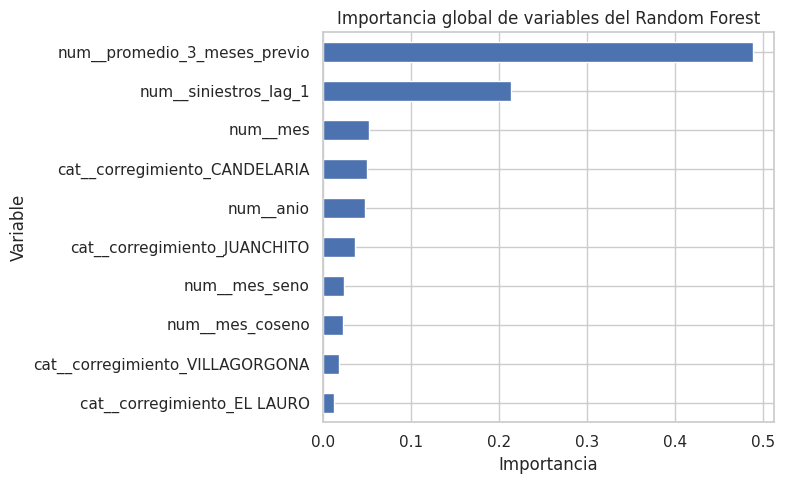

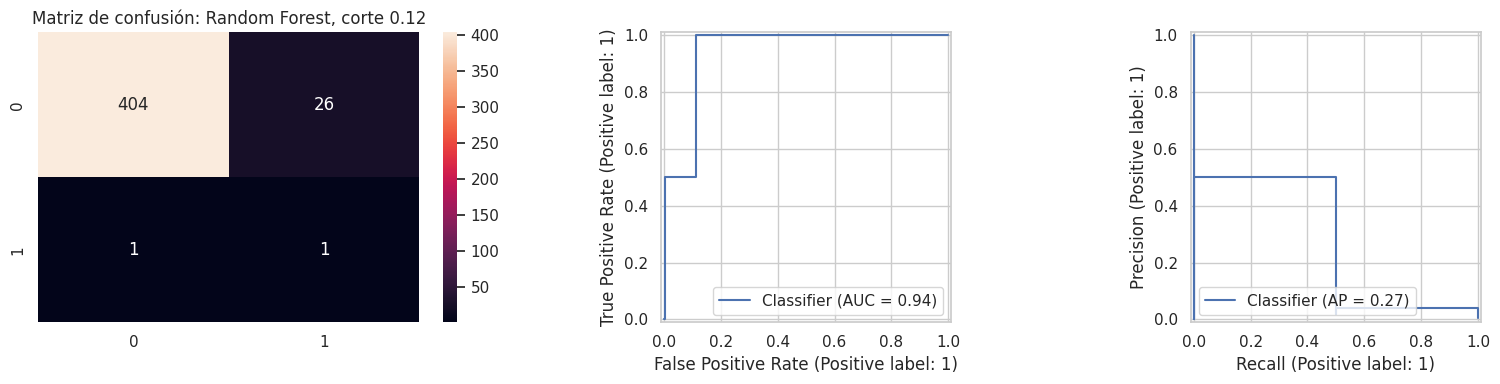

Resultado final 2025 | umbral=0.12 | TN=404 | FP=26 | FN=1 | TP=1


In [14]:
rf_final = Pipeline([
    ("prep", preprocessor(clf_cat, clf_num)),
    ("model", RandomForestClassifier(
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])
rf_final.set_params(**clf_best_params["Random Forest"])
rf_final.fit(mon_train[clf_features], mon_train["alta_siniestralidad"])
test_proba = rf_final.predict_proba(mon_test[clf_features])[:, 1]
test_label = (test_proba >= DECISION_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(mon_test["alta_siniestralidad"], test_label, labels=[0, 1]).ravel()

classification_test_results = pd.DataFrame([{
    "Modelo": "Random Forest",
    "Umbral": DECISION_THRESHOLD,
    "Accuracy": accuracy_score(mon_test["alta_siniestralidad"], test_label),
    "Precision": precision_score(mon_test["alta_siniestralidad"], test_label, zero_division=0),
    "Recall": recall_score(mon_test["alta_siniestralidad"], test_label, zero_division=0),
    "F1": f1_score(mon_test["alta_siniestralidad"], test_label, zero_division=0),
    "AUC-ROC": roc_auc_score(mon_test["alta_siniestralidad"], test_proba),
    "AUC-PR": average_precision_score(mon_test["alta_siniestralidad"], test_proba),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])
display(classification_test_results.round(4))

train_prevalence = mon_train["alta_siniestralidad"].mean()
baseline_proba = np.repeat(train_prevalence, len(mon_test))
baseline_label = (baseline_proba >= 0.50).astype(int)
baseline_results = pd.DataFrame([{
    "Modelo": "Baseline: clase mayoritaria",
    "Accuracy": accuracy_score(mon_test["alta_siniestralidad"], baseline_label),
    "Precision": precision_score(mon_test["alta_siniestralidad"], baseline_label, zero_division=0),
    "Recall": recall_score(mon_test["alta_siniestralidad"], baseline_label, zero_division=0),
    "F1": f1_score(mon_test["alta_siniestralidad"], baseline_label, zero_division=0),
    "AUC-ROC": roc_auc_score(mon_test["alta_siniestralidad"], baseline_proba),
    "AUC-PR": average_precision_score(mon_test["alta_siniestralidad"], baseline_proba)
}])
display(baseline_results.round(4))

SENSITIVITY_THRESHOLD = 0.02
sensitivity_label = (test_proba >= SENSITIVITY_THRESHOLD).astype(int)
tn_s, fp_s, fn_s, tp_s = confusion_matrix(mon_test["alta_siniestralidad"], sensitivity_label, labels=[0, 1]).ravel()
print(f"Sensibilidad diagnóstica con corte {SENSITIVITY_THRESHOLD:.2f}:", {"TN": tn_s, "FP": fp_s, "FN": fn_s, "TP": tp_s})

positive_cases = mon_test.loc[
    mon_test["alta_siniestralidad"] == 1,
    ["corregimiento", "periodo", "siniestros_mes", "alta_siniestralidad"]
].copy()
positive_cases["score_alta"] = test_proba[mon_test["alta_siniestralidad"].to_numpy() == 1]
display(positive_cases)

feature_names = rf_final.named_steps["prep"].get_feature_names_out()
feature_importance_clf = pd.DataFrame({
    "variable": feature_names,
    "importancia": rf_final.named_steps["model"].feature_importances_
}).sort_values("importancia", ascending=False).head(10)
display(feature_importance_clf.round(4))
feature_importance_clf.sort_values("importancia").plot.barh(
    x="variable",
    y="importancia",
    legend=False,
    figsize=(8, 5)
)
plt.title("Importancia global de variables del Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.heatmap(
    confusion_matrix(mon_test["alta_siniestralidad"], test_label),
    annot=True,
    fmt="d",
    ax=axes[0]
)
axes[0].set_title(f"Matriz de confusión: Random Forest, corte {DECISION_THRESHOLD:.2f}")
RocCurveDisplay.from_predictions(mon_test["alta_siniestralidad"], test_proba, ax=axes[1])
PrecisionRecallDisplay.from_predictions(mon_test["alta_siniestralidad"], test_proba, ax=axes[2])
plt.tight_layout()
plt.show()
print(f"Resultado final 2025 | umbral={DECISION_THRESHOLD:.2f} | TN={tn} | FP={fp} | FN={fn} | TP={tp}")

### Análisis e interpretación de la clasificación

Los valores exactos del test de 2025 aparecen en la tabla, la matriz de confusión y las curvas generadas arriba. La lectura no se hace solamente con Accuracy porque la clase ALTA representa una fracción muy pequeña del conjunto.

Por eso revisamos de manera conjunta **Precision, Recall, F1, ROC-AUC, PR-AUC y los falsos positivos y falsos negativos**. ROC-AUC y PR-AUC usan el score continuo del modelo, mientras que Precision, Recall, F1 y la matriz de confusión dependen del umbral que se fijó previamente con 2024.

El punto más importante es que **2025 no se usa para volver a escoger el corte**. Si el resultado final muestra errores, estos se reportan como una limitación de generalización y no se modifica el modelo hasta que el test se vea mejor.

También se muestra una importancia global de variables del Random Forest. Esta gráfica ayuda a entender qué variables usa más el modelo en términos generales, pero no prueba causalidad ni explica por sí sola cada predicción individual.

### Registro de IA — Prompt 7: resultado final e iteración que no se aceptó

**Prompt usado**

> Después de evaluar 2025, el modelo todavía comete falsos positivos o falsos negativos. Si encuentro un corte que mejora el resultado del test, ¿debería cambiar el umbral final?

**Respuesta o crítica que tomamos en cuenta**

No. Cambiar otra vez el umbral después de observar 2025 convertiría el test en parte del proceso de ajuste. También se señaló que los casos positivos que el modelo no detecte no deben llamarse outliers solamente por haber sido difíciles de clasificar.

**Decisión del equipo**

Se conserva el umbral elegido únicamente con **2024**. La prueba con corte **0,02** se mantiene solo como análisis de sensibilidad para mostrar cómo cambia el equilibrio entre Recall y falsas alertas. No se utiliza para reoptimizar después de conocer 2025.

Esta es una iteración importante del proyecto: se prueba una alternativa, se observa su costo y se decide si se incorpora o no sin utilizar el test como conjunto de ajuste.

### Evidencia de iteración y mejora

El proyecto no siguió una sola línea de principio a fin. Hubo decisiones que cambiaron a partir de los resultados intermedios:

1. **Preprocesamiento:** se decidió no eliminar automáticamente los conteos altos como outliers porque podían ser meses reales de alta siniestralidad.
2. **Features:** se mantuvieron rezagos y promedio de meses previos porque el EDA mostró estructura temporal. Se excluyeron variables del propio mes objetivo para evitar fuga de información.
3. **Definición de ALTA:** se mantuvo el corte de 5 siniestros aunque produjera desbalance. No se cambió la etiqueta solo para mejorar métricas.
4. **Optimización:** los hiperparámetros se ajustan con 2024 y el test 2025 queda fuera de esa búsqueda.
5. **Umbral de clasificación:** la versión anterior usaba un corte fijo. En esta revisión se corrige el procedimiento y el corte se selecciona directamente con 2024 usando F1, antes de abrir el test.
6. **Después del test:** cualquier corte alternativo probado con 2025 se presenta como sensibilidad y no como una nueva selección del modelo.

Esto deja visible qué se cambió, por qué se cambió y qué decisiones se rechazaron.

### 5.3 Del modelo a la aplicación

La aplicación utiliza los dos modelos de forma independiente:

- La regresión entrega un conteo estimado de siniestros.
- La clasificación entrega un score para la clase ALTA y lo compara con el **umbral seleccionado en la validación 2024**.

Es importante no confundir dos conceptos distintos:

- **5 siniestros** define qué observaciones históricas pertenecen a la clase ALTA.
- El **umbral de decisión** se aplica al score del clasificador para producir ALTA / NO ALTA y se obtiene con la validación temporal.

El score de `predict_proba` se presenta como una salida del modelo y no como una probabilidad real perfectamente calibrada. La app pide corregimiento, año y mes porque esa es la resolución temporal que utiliza el modelo.

Para la versión desplegada, el umbral que produzca este cuaderno debe guardarse junto con el modelo y ser el mismo que use Streamlit. Así evitamos que notebook y aplicación terminen tomando decisiones con cortes diferentes.

### Registro de IA — Prompt 8: revisión de la aplicación web

**Prompt usado**

> Mi app está pensada para la Secretaría de Tránsito y muestra un conteo estimado, una alerta ALTA / NO ALTA y un score. ¿Qué le falta para que un usuario no técnico entienda el resultado y pueda usarlo sin tratar la predicción como una verdad automática?

**Respuesta o crítica que tomamos en cuenta**

No basta con mostrar una predicción. El usuario necesita contexto, una explicación sencilla de los dos resultados, acciones sugeridas y alguna forma de entender qué información usa el modelo. También se debe evitar presentar el score como una probabilidad real perfectamente calibrada.

**Decisión del equipo**

La app mantiene separados el conteo de regresión y la alerta de clasificación, explica que la salida es un apoyo y propone acciones de revisión, monitoreo y validación en campo. Como mejora de transparencia, la versión final de la app debe incluir una referencia a la importancia global de variables calculada en este cuaderno y cargar el mismo umbral que resulte de la validación 2024.

## 6. Ética, Sesgos y Limitaciones

### Sesgos y riesgos identificados

- Los datos reflejan lo que fue registrado. Puede existir subregistro y diferencias en la forma de reportar entre años o zonas.
- Una zona con más registros no necesariamente tiene mayor riesgo causal; también puede tener más tránsito, mayor vigilancia o mejor reporte.
- Hay posibles inconsistencias en nombres territoriales que no se deben fusionar sin verificación.
- La clase ALTA es muy escasa. Esto limita la cantidad de ejemplos con los que el clasificador puede aprender.
- El conjunto no incluye variables que pueden ser importantes, como flujo vehicular, clima, obras, eventos, controles o cambios de infraestructura.
- Un falso negativo puede dejar sin alerta un periodo realmente ALTA, mientras que demasiados falsos positivos pueden saturar la capacidad de revisión de la entidad.

### Uso responsable

La herramienta debe apoyar **prevención y revisión**, no sanciones automáticas. Tampoco debe usarse para estigmatizar un corregimiento.

Sin una valoración real de costos por parte de la Secretaría no podemos afirmar que un tipo de error sea siempre preferible al otro. Esa decisión necesitaría participación del stakeholder.

### Limitación principal encontrada

La principal dificultad de la clasificación es que los eventos ALTA son muy poco frecuentes. Esto hace que la frontera binaria sea sensible al umbral y que métricas como Accuracy puedan verse bien incluso cuando la clase positiva sigue siendo difícil de detectar.

Los casos positivos que el modelo no detecte no se consideran automáticamente datos atípicos o incorrectos. Pueden ser eventos reales que las variables disponibles no logran explicar de forma estable.

### Registro de IA — Prompt 9: ética y posibles daños

**Prompt usado**

> Si una Secretaría usa una alerta mensual por corregimiento para priorizar acciones preventivas, ¿qué daños o sesgos podrían aparecer aunque el modelo tenga buenas métricas?

**Respuesta o crítica que tomamos en cuenta**

Una zona con más registros podría recibir más controles aunque el número observado se deba en parte a mayor exposición, vigilancia o calidad del reporte. También existe el riesgo de tratar una predicción como certeza, estigmatizar territorios o automatizar decisiones que deberían revisar funcionarios con conocimiento local.

**Decisión del equipo**

La herramienta se plantea únicamente como apoyo a prevención. No se proponen sanciones automáticas ni decisiones basadas solamente en la salida del modelo. La validación en campo y el criterio de la Secretaría siguen siendo necesarios, y en trabajo futuro se plantea incorporar variables de exposición para reducir interpretaciones injustas.

## 7. Conclusiones y Trabajo Futuro

El proyecto parte de una necesidad concreta: usar datos históricos para apoyar una decisión preventiva antes del siguiente mes. Para ello se construyeron dos problemas complementarios: estimar el número de siniestros y clasificar si un corregimiento-mes entra en una condición ALTA.

En regresión, el modelo final se selecciona con validación temporal y se compara contra una referencia basada en el promedio histórico. Las métricas MSE, RMSE, MAE y R² permiten mostrar tanto el error como la parte de variación que todavía queda sin explicar.

En clasificación, la principal dificultad es la rareza de la clase ALTA. Los hiperparámetros se ajustan con 2024 y, para el Random Forest operativo, el umbral se escoge también con 2024 usando F1. Después de eso, **2025 queda como prueba final y no se vuelve a utilizar para cambiar el corte**.

El análisis de sensibilidad con un umbral muy bajo se mantiene únicamente para mostrar el intercambio entre detectar más positivos y producir más falsas alertas. No se usa para maquillar el resultado final.

### Trabajo futuro

Una siguiente versión debería:

1. Incorporar más años y, sobre todo, más ejemplos de meses ALTA.
2. Integrar exposición vehicular, clima, obras, eventos, controles y variables de infraestructura.
3. Revisar y homologar categorías territoriales con apoyo de la entidad.
4. Validar con la Secretaría el costo real de falsos positivos y falsos negativos.
5. Evaluar el sistema con usuarios reales y medir si la información cambia o mejora decisiones preventivas.
6. Revisar calibración del score antes de interpretarlo como una probabilidad en un uso operativo.
7. Incorporar en la app una explicación sencilla de importancia de variables y guardar el mismo umbral seleccionado en el cuaderno.

La conclusión final es que el modelo puede ser una herramienta de apoyo, pero todavía necesita más información y validación con el stakeholder antes de convertirse en un sistema de decisión real.